In [ ]:
import kagglehub
import pandas as pd

import os

# 1. Download the dataset and FORCE it to ignore the cache
dataset_folder = kagglehub.dataset_download(
    "muhammadshahidazeem/customer-churn-dataset",
    force_download=True
)

# 2. Point directly to the CSV file inside that downloaded folder
file_path = os.path.join(dataset_folder, "customer_churn_dataset-training-master.csv")

# 3. Read it using standard Pandas
df = pd.read_csv(file_path)

print("Fresh data loaded successfully!\n")
print(df.head())

Using Colab cache for faster access to the 'customer-churn-dataset' dataset.
Fresh data loaded successfully!

   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1 

In [ ]:

# Handdle Gender

df_gender = df.dropna(subset=['Gender'])
gender_counts = df_gender['Gender'].value_counts()

mapping_dict = {category: rank for rank, category in enumerate(gender_counts.index)}



df_gender['Gender'] = df_gender['Gender'].map(mapping_dict)
df_gender.isna().sum()

/tmp/ipykernel_375/2997702370.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gender['Gender'] = df_gender['Gender'].map(mapping_dict)


,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [ ]:
# Convert types to int
columns_to_convert_to_int = ['CustomerID', 'Age', 'Support Calls']

df = df.dropna()
df[columns_to_convert_to_int] = df[columns_to_convert_to_int].astype(int)


#Check_if_types_are_numeric

# 2. Check and convert types to numeric if necessary
numeric_coll = ['Usage Frequency','Support Calls','Payment Delay','Total Spend','Last Interaction']

df[numeric_coll] = df[numeric_coll].apply(pd.to_numeric, errors='coerce')


In [ ]:
# We have only 3 categories of lenght so we map them
contract_length = df['Contract Length'].unique()


df_length = df.copy()
df_length = df_length.dropna(subset=['Contract Length'])


df_length['Contract Length'] = df_length['Contract Length'].str.strip()
mapping_dict_length = {'Annual':12, 'Monthly':1, 'Quarterly':6}

df_length['Contract Length'] = df_length['Contract Length'].map(mapping_dict_length)

df_length.head()


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,Female,39.0,14.0,5,18.0,Standard,12,932.0,17.0,1.0
1,3,65,Female,49.0,1.0,10,8.0,Basic,1,557.0,6.0,1.0
2,4,55,Female,14.0,4.0,6,18.0,Basic,6,185.0,3.0,1.0
3,5,58,Male,38.0,21.0,7,7.0,Standard,1,396.0,29.0,1.0
4,6,23,Male,32.0,20.0,5,8.0,Basic,1,617.0,20.0,1.0


In [ ]:
# As the number of subscriptions are simmilar, we can make it so that premium has the highest priority, basic the lowest and standard is in the middle

mapping_dict_type = {'Premium': 3, 'Basic': 1, 'Standard':2}

df_subsr_type = df.copy()
df_subsr_type = df_subsr_type.dropna(subset=['Subscription Type'])
df_subsr_type['Subscription Type'] = df_subsr_type['Subscription Type'].map(mapping_dict_type)

df_subsr_type.head()


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,Female,39.0,14.0,5,18.0,2,Annual,932.0,17.0,1.0
1,3,65,Female,49.0,1.0,10,8.0,1,Monthly,557.0,6.0,1.0
2,4,55,Female,14.0,4.0,6,18.0,1,Quarterly,185.0,3.0,1.0
3,5,58,Male,38.0,21.0,7,7.0,2,Monthly,396.0,29.0,1.0
4,6,23,Male,32.0,20.0,5,8.0,1,Monthly,617.0,20.0,1.0


In [ ]:

df_final = df.copy()

df_final.set_index('CustomerID', inplace=True)
df_gender.set_index('CustomerID', inplace=True)
df_length.set_index('CustomerID', inplace=True)
df_subsr_type.set_index('CustomerID', inplace=True)

df_final.update(df_gender[['Gender']])
df_final.update(df_length[['Contract Length']])
df_final.update(df_subsr_type[['Subscription Type']])


df_gender.reset_index(inplace=True)
df_length.reset_index(inplace=True)
df_subsr_type.reset_index(inplace=True)
df_final.reset_index(inplace=True)

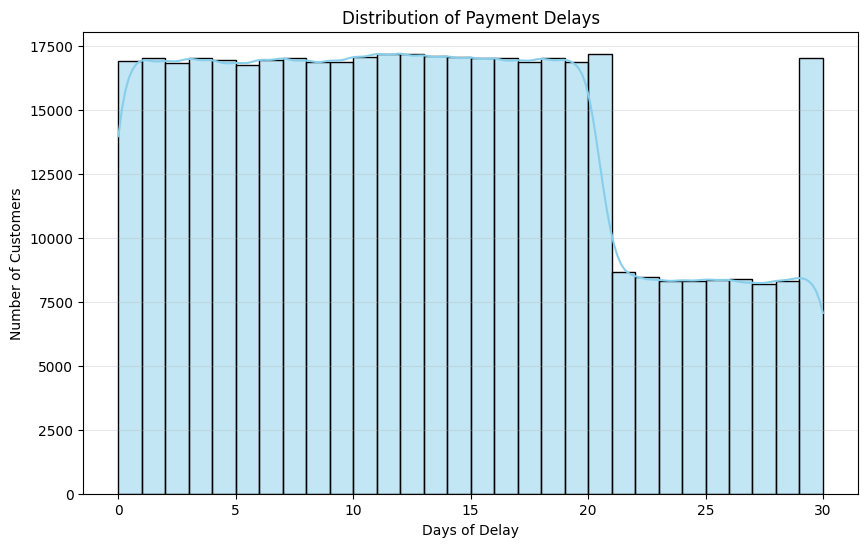

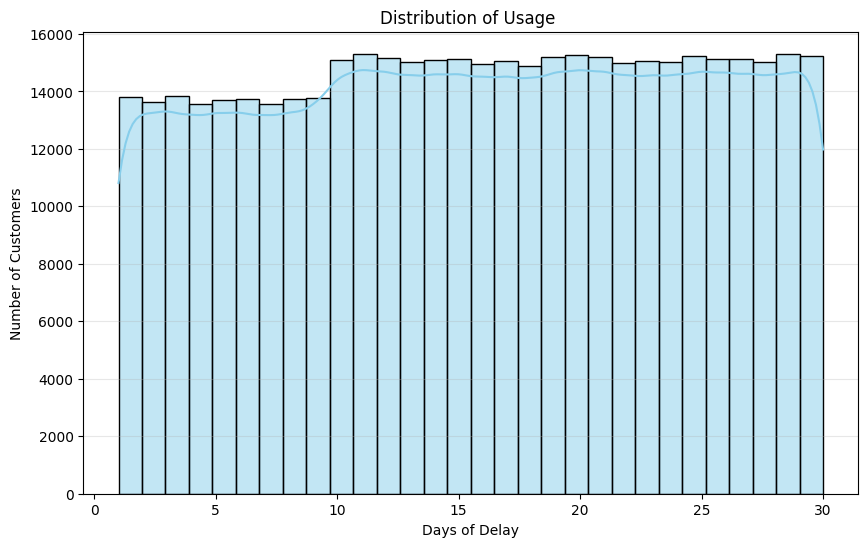

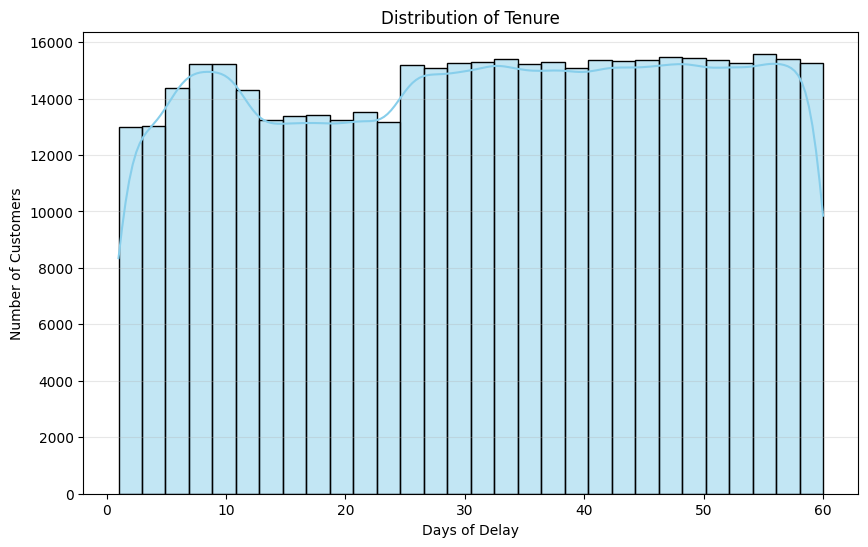

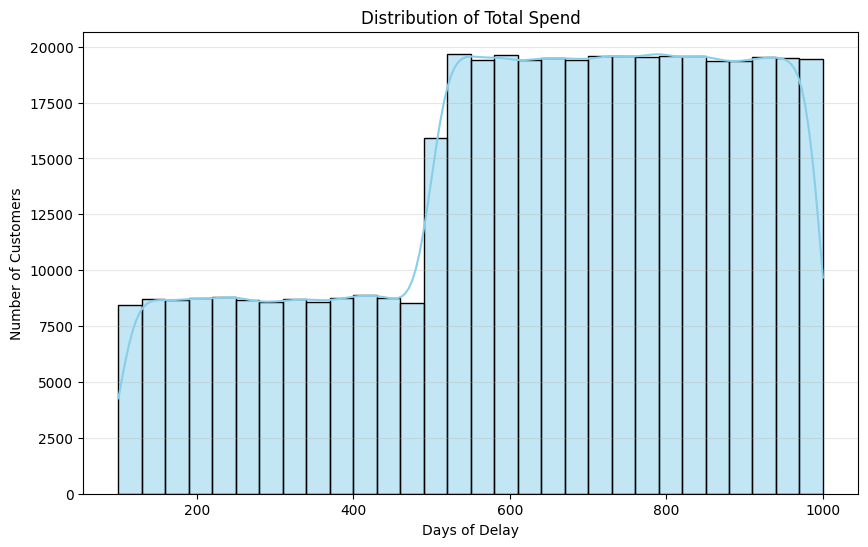

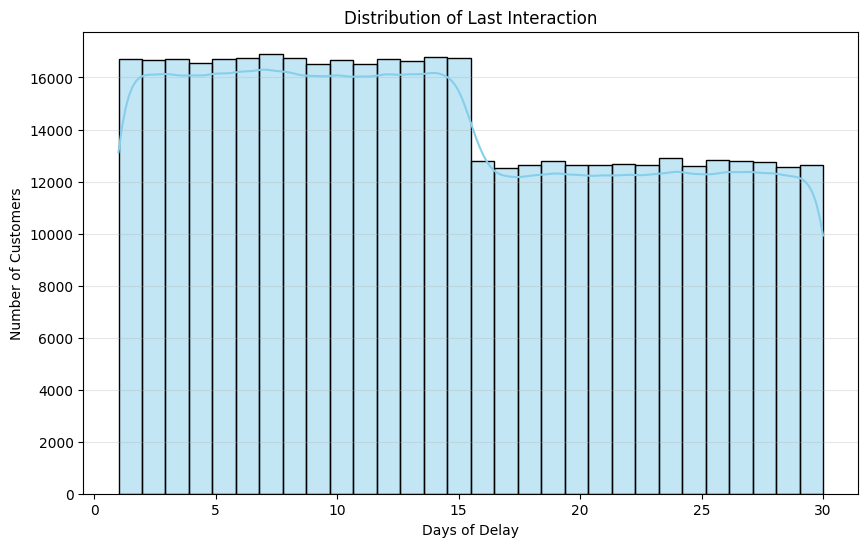

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Use a Histogram with a KDE (smooth line) to see the spread of delays
sns.histplot(df_final['Payment Delay'], bins=30, kde=True, color='skyblue')

plt.title('Distribution of Payment Delays')
plt.xlabel('Days of Delay')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))

# Use a Histogram with a KDE (smooth line) to see the spread of delays
sns.histplot(df_final['Usage Frequency'], bins=30, kde=True, color='skyblue')

plt.title('Distribution of Usage ')
plt.xlabel('Days of Delay')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()




plt.figure(figsize=(10, 6))

sns.histplot(df_final['Tenure'], bins=30, kde=True, color='skyblue')

plt.title('Distribution of Tenure')
plt.xlabel('Days of Delay')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))

sns.histplot(df_final['Total Spend'], bins=30, kde=True, color='skyblue')

plt.title('Distribution of Total Spend')
plt.xlabel('Days of Delay')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()



plt.figure(figsize=(10, 6))

sns.histplot(df_final['Last Interaction'], bins=30, kde=True, color='skyblue')

plt.title('Distribution of Last Interaction')
plt.xlabel('Days of Delay')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()



In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

collumns_to_scale = ['Age', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']

df_final[collumns_to_scale] = scaler.fit_transform(df_final[collumns_to_scale])



df_final.head(20)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,-0.753326,1,39.0,-0.210511,0.454549,0.609620,2,12,1.247427,0.293052,1.0
1,3,2.059646,1,49.0,-1.724562,2.083100,-0.601319,1,1,-0.309865,-0.986584,1.0
2,4,1.255940,1,14.0,-1.375166,0.780259,0.609620,1,6,-1.854698,-1.335575,1.0
3,5,1.497051,0,38.0,0.604748,1.105969,-0.722413,2,1,-0.978462,1.689018,1.0
4,6,-1.315921,0,32.0,0.488282,0.454549,-0.601319,1,1,-0.060698,0.642043,1.0
5,8,0.934457,0,33.0,1.070610,1.757390,1.578372,3,12,-2.087253,-0.753923,1.0
6,9,1.497051,1,49.0,-0.443442,-0.196871,0.367433,2,6,0.786469,1.107365,1.0
7,10,1.255940,1,37.0,-0.909304,0.128839,0.246339,3,12,-0.774976,1.805348,1.0
8,11,-0.029991,0,12.0,-1.258700,1.105969,-1.085694,2,6,1.401080,-0.172270,1.0
9,12,1.979275,1,3.0,1.070610,-0.522581,-0.238037,2,6,-0.899559,1.689018,1.0


<Axes: >

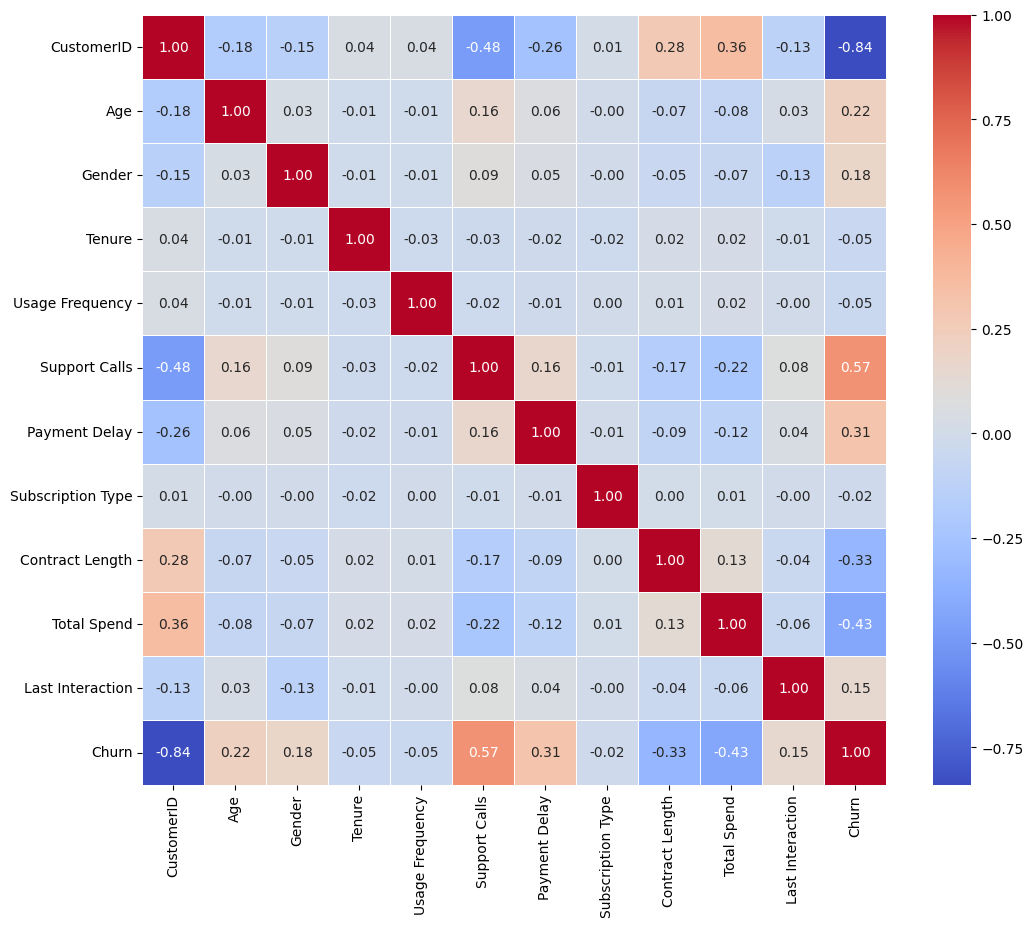

In [ ]:
corr_matrix = df_final.corr()

# 2. Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# 3. Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

In [ ]:
collumn_to_keep = ['Age','Gender','Total Spend','Payment Delay','Last Interaction','Contract Length','Churn']

df_train = df_final[collumn_to_keep]
df_train.head()

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier


y = df_train['Churn']

X = df_train.drop('Churn', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


print(len(X_train))
print(len(X_test))

352665
88167


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)





NameError: name 'ConfusionMatrixDisplay' is not defined

              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94     38257
         1.0       0.99      0.91      0.95     49910

    accuracy                           0.95     88167
   macro avg       0.94      0.95      0.95     88167
weighted avg       0.95      0.95      0.95     88167



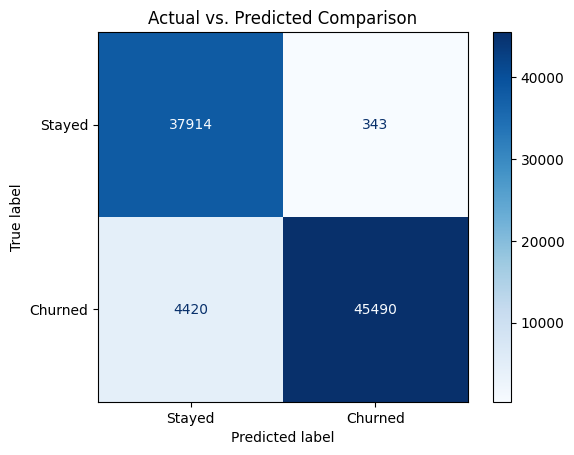

In [ ]:
# 3. Plot it
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print(classification_report(y_test, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Actual vs. Predicted Comparison')
plt.show()


/tmp/ipykernel_375/2098288247.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Score', y='Feature', data=feature_importance_df, palette='viridis')


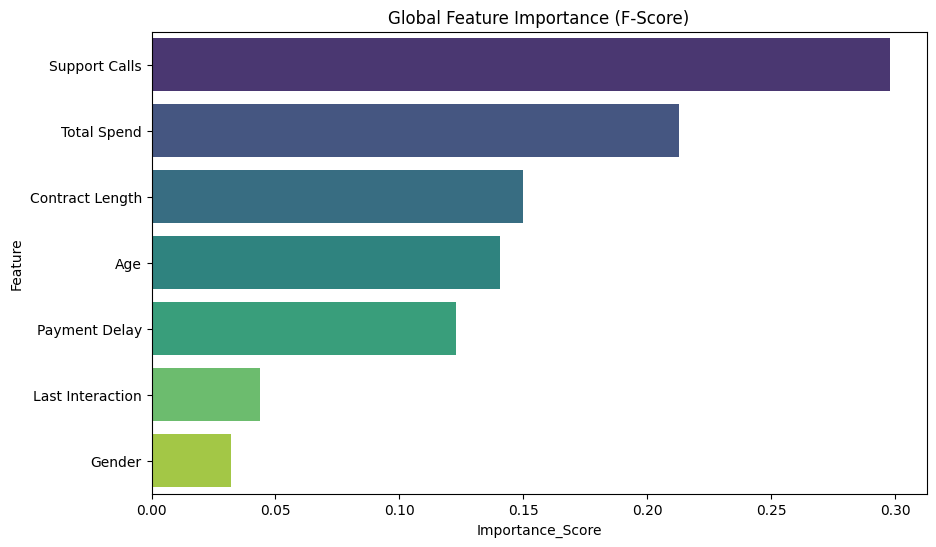

In [ ]:
import seaborn as sns
import numpy as np
importances = model.feature_importances_
feature_names = X.columns # X is your training features dataframe

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance_Score': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance_Score', ascending=False)

# 3. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance_Score', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Global Feature Importance (F-Score)')
plt.show()